**Load Data**

In [1]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

path = kagglehub.dataset_download("avineshprabhakaran/loan-eligibility-prediction")

print("Path to dataset files:", path)

/Users/kavishkaimalsha/Desktop/Loan approval Prediction/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/kavishkaimalsha/.cache/kagglehub/datasets/avineshprabhakaran/loan-eligibility-prediction/versions/3


In [2]:
df = pd.read_csv(f'{path}/Loan Eligibility Prediction.csv')

**Data Uderstanding**

In [3]:
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [4]:
df.tail()
df.drop(columns=['Customer_ID'],inplace=True)

**Sanitizer Check**

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Gender              614 non-null    str    
 1   Married             614 non-null    str    
 2   Dependents          614 non-null    int64  
 3   Education           614 non-null    str    
 4   Self_Employed       614 non-null    str    
 5   Applicant_Income    614 non-null    int64  
 6   Coapplicant_Income  614 non-null    float64
 7   Loan_Amount         614 non-null    int64  
 8   Loan_Amount_Term    614 non-null    int64  
 9   Credit_History      614 non-null    int64  
 10  Property_Area       614 non-null    str    
 11  Loan_Status         614 non-null    str    
dtypes: float64(1), int64(5), str(6)
memory usage: 57.7 KB


In [6]:
df.isnull().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
Applicant_Income      0
Coapplicant_Income    0
Loan_Amount           0
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

**Encode Categorical Data**

In [8]:
for i in df.select_dtypes('string').columns:
    print(f'{df[i].unique()}')

df['Gender'] = df['Gender'].map({'Male':1, 'Female':0})
df['Married'] = df['Married'].map({'Yes':1, 'No':0})
df['Education'] = df['Education'].map({'Graduate':1, 'Not Graduate':0})
df['Self_Employed'] = df['Self_Employed'].map({'Yes':1, 'No':0})
df['Loan_Status'] = df['Loan_Status'].map({'Y':1, 'N':0})

#One hot encording
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=True, dtype=int)

<StringArray>
['Female', 'Male']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str
<StringArray>
['No', 'Yes']
Length: 2, dtype: str
<StringArray>
['Urban', 'Semiurban', 'Rural']
Length: 3, dtype: str
<StringArray>
['N', 'Y']
Length: 2, dtype: str


**EDA**

In [9]:
df.describe()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.812704,0.649837,0.856678,0.781759,0.148208,5403.459283,1621.245798,142.022801,338.892508,0.850163,0.687296,0.379479,0.328990
std,0.390467,0.477410,1.216651,0.413389,0.355596,6109.041673,2926.248369,87.083089,69.716355,0.357203,0.463973,0.485653,0.470229
min,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,1.000000,0.000000,2877.500000,0.000000,98.000000,360.000000,1.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,1.000000,0.000000,3812.500000,1188.500000,125.000000,360.000000,1.000000,1.000000,0.000000,0.000000
75%,1.000000,1.000000,2.000000,1.000000,0.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,4.000000,1.000000,1.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,1.000000,1.000000,1.000000


**Plot Histogram and Boxplot to get Numerical Understanding and check outliers about dataset**

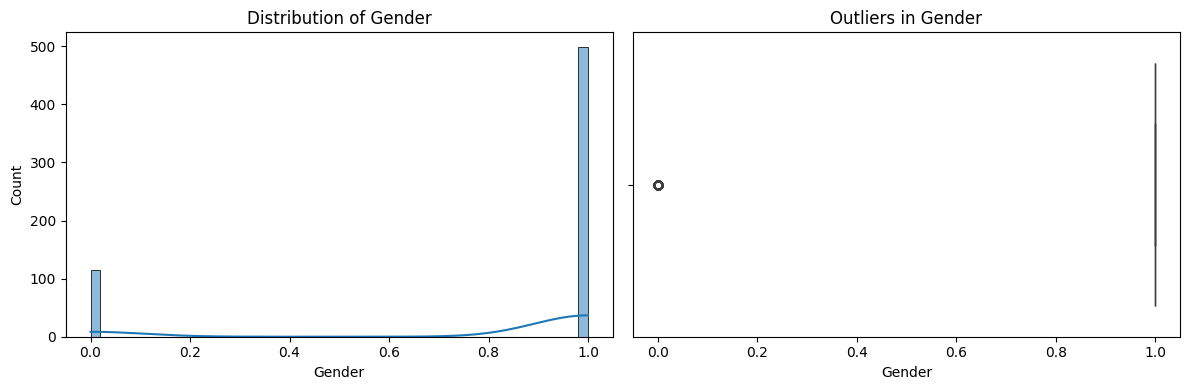

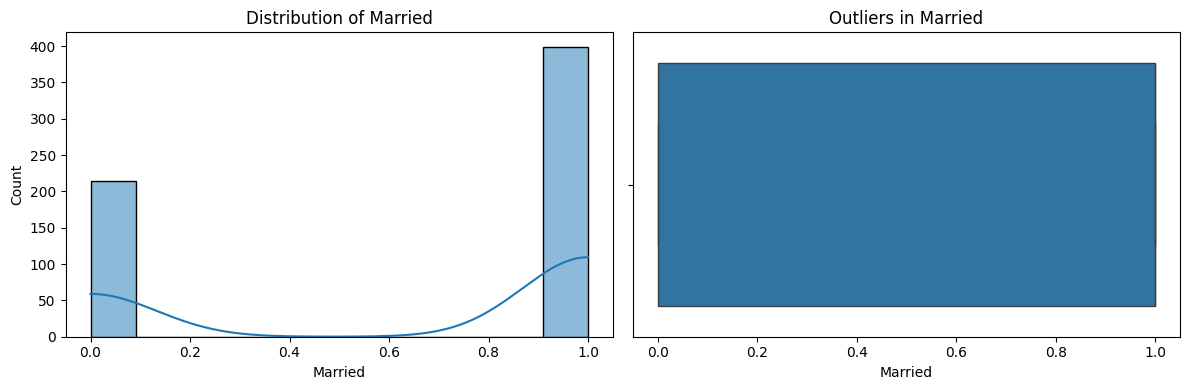

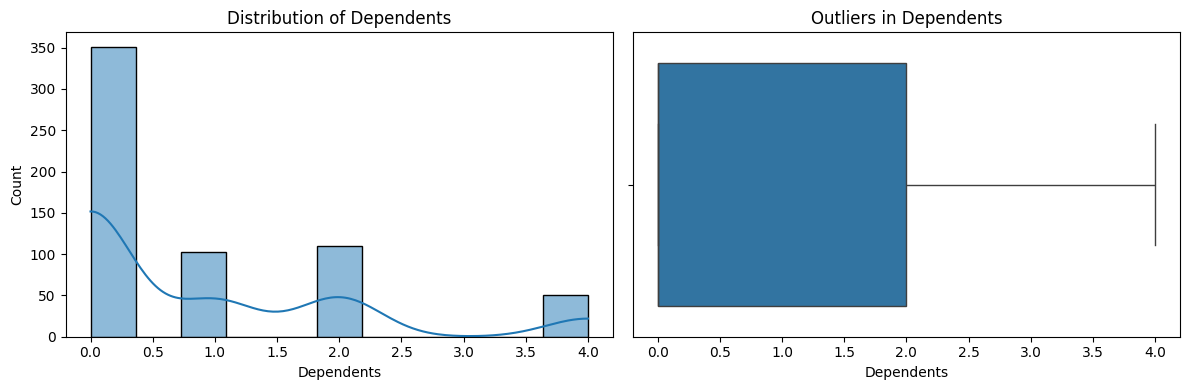

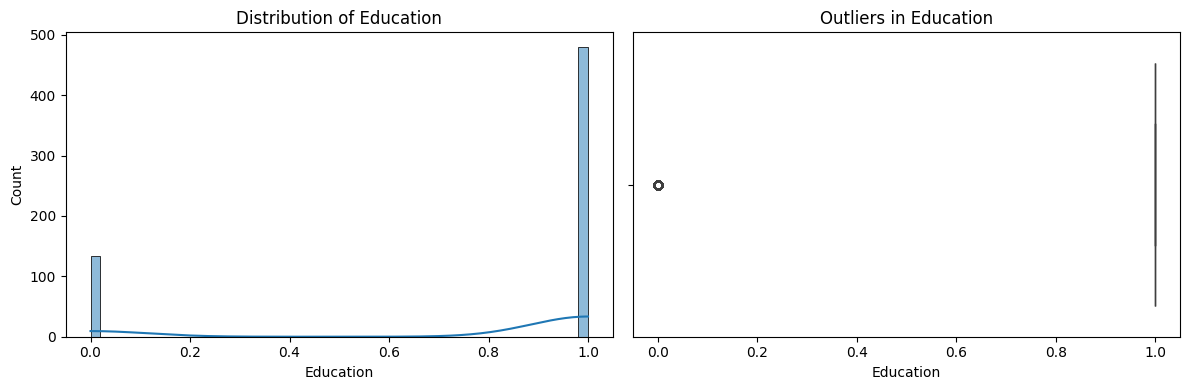

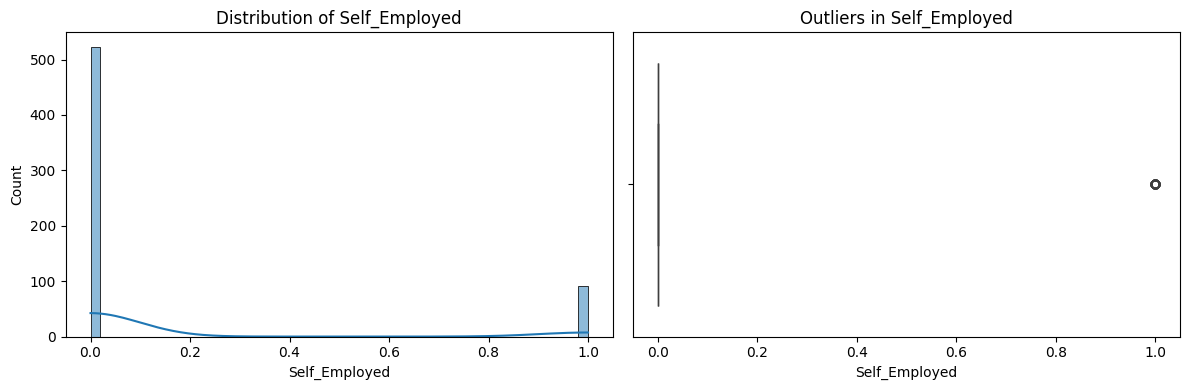

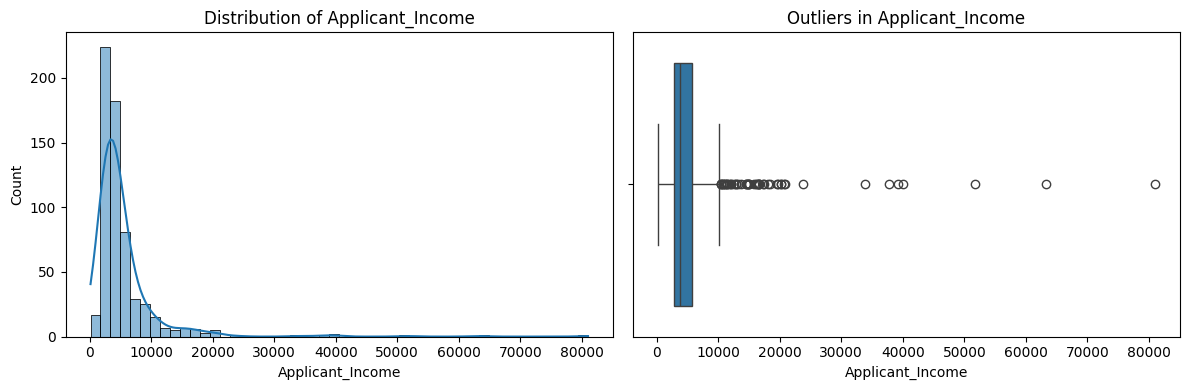

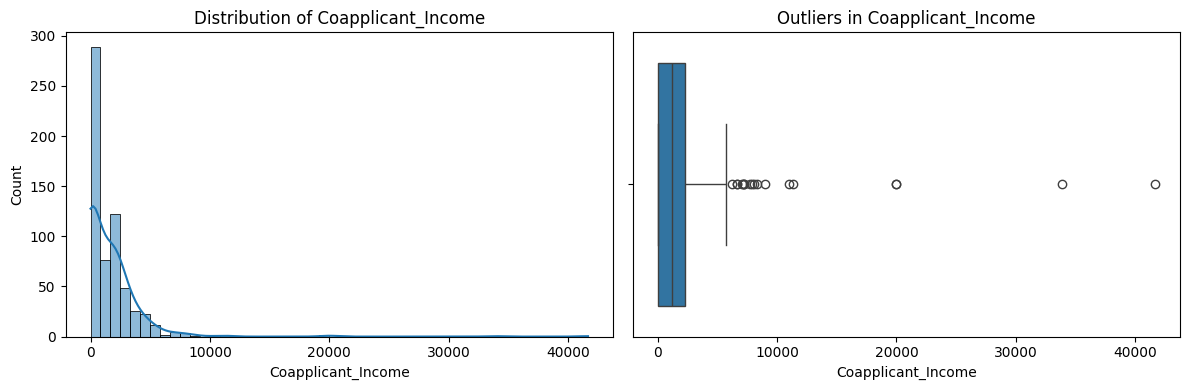

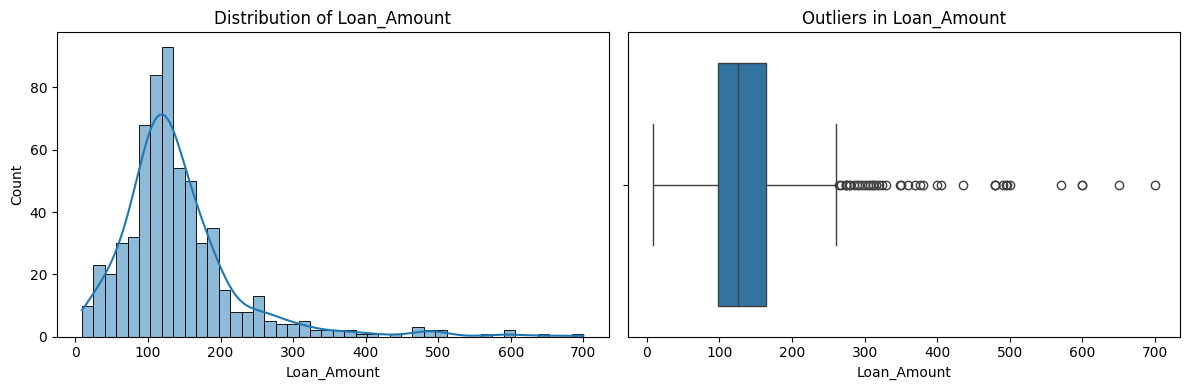

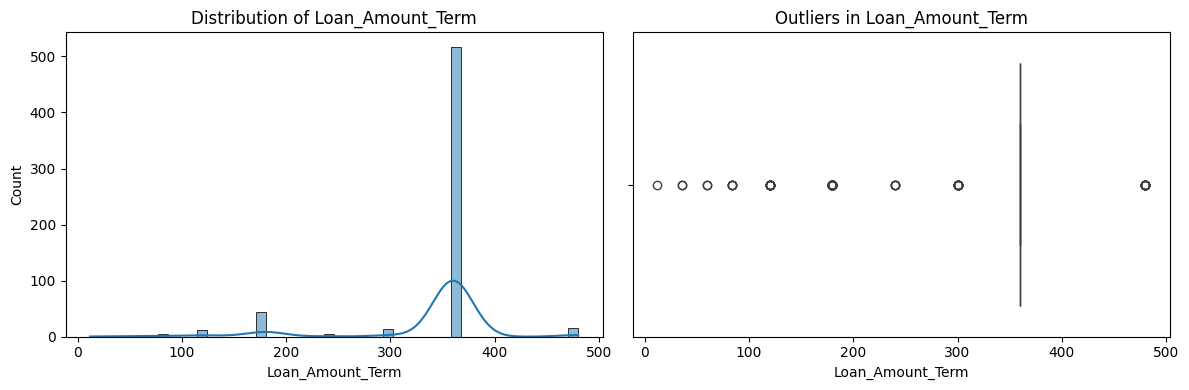

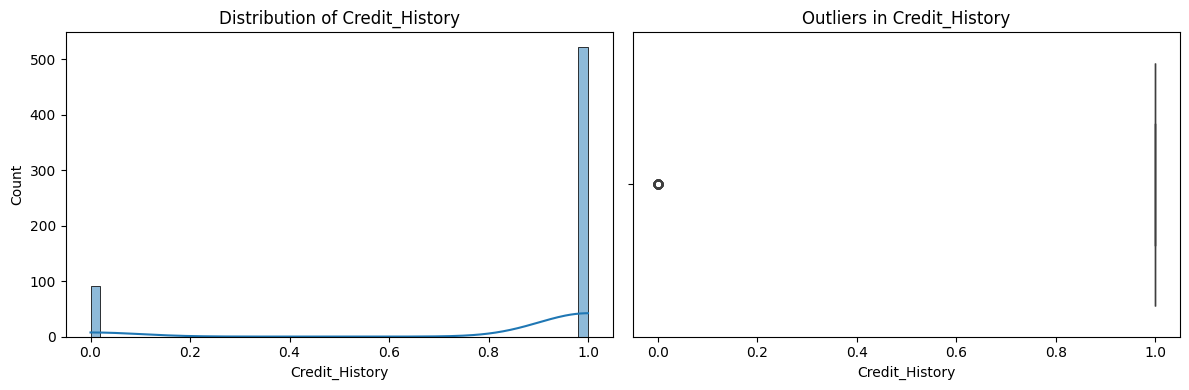

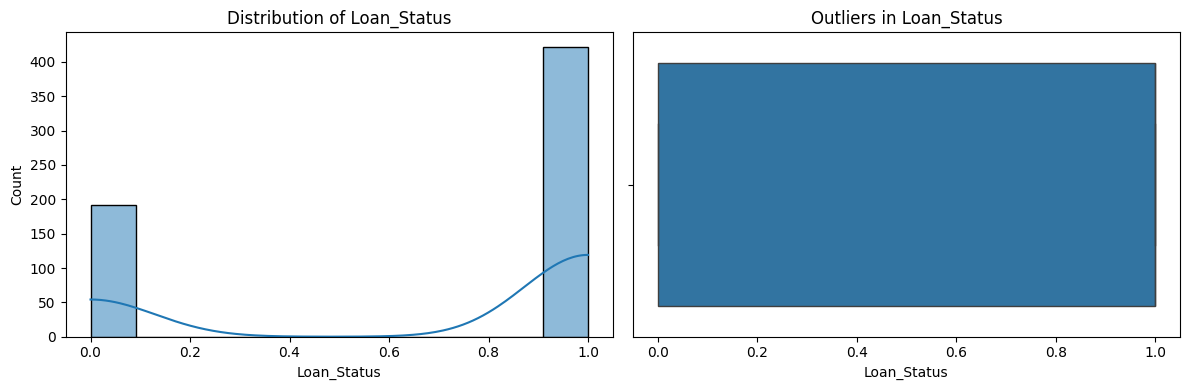

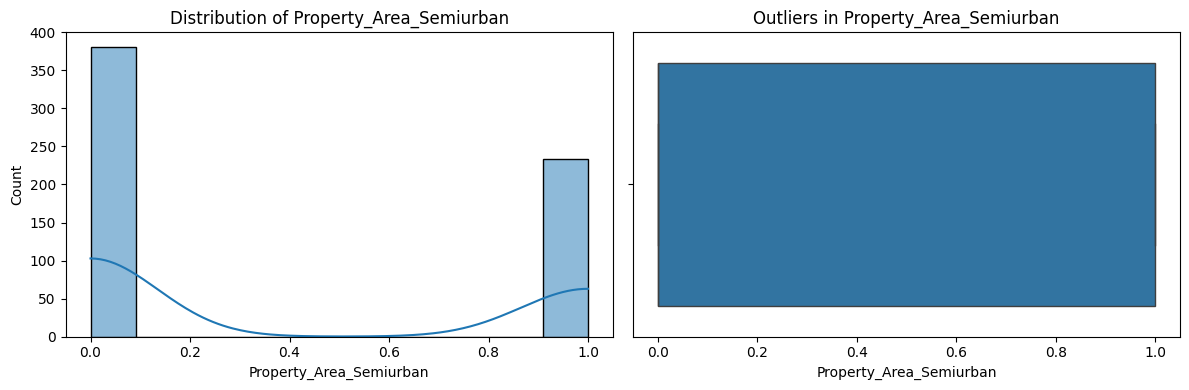

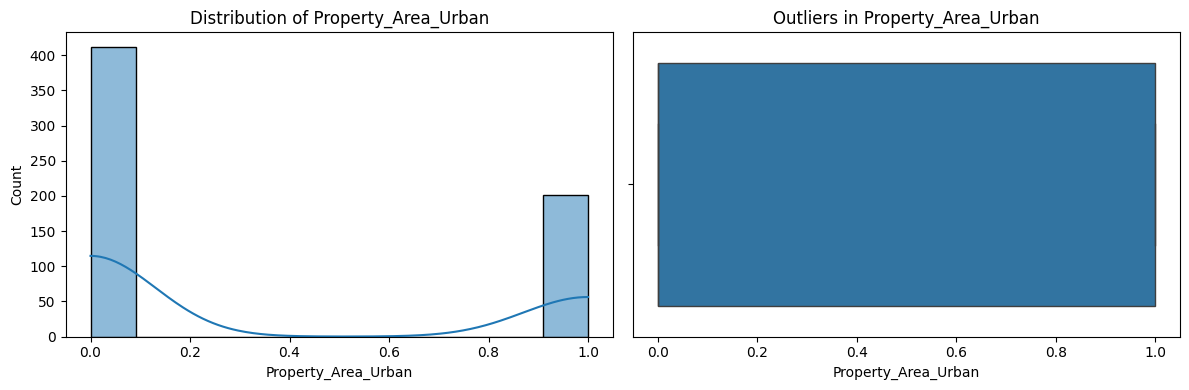

In [10]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    
    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f"Distribution of {col}")
    
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"Outliers in {col}")
    
    plt.tight_layout()
    plt.show()

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Gender                   614 non-null    int64  
 1   Married                  614 non-null    int64  
 2   Dependents               614 non-null    int64  
 3   Education                614 non-null    int64  
 4   Self_Employed            614 non-null    int64  
 5   Applicant_Income         614 non-null    int64  
 6   Coapplicant_Income       614 non-null    float64
 7   Loan_Amount              614 non-null    int64  
 8   Loan_Amount_Term         614 non-null    int64  
 9   Credit_History           614 non-null    int64  
 10  Loan_Status              614 non-null    int64  
 11  Property_Area_Semiurban  614 non-null    int64  
 12  Property_Area_Urban      614 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 62.5 KB


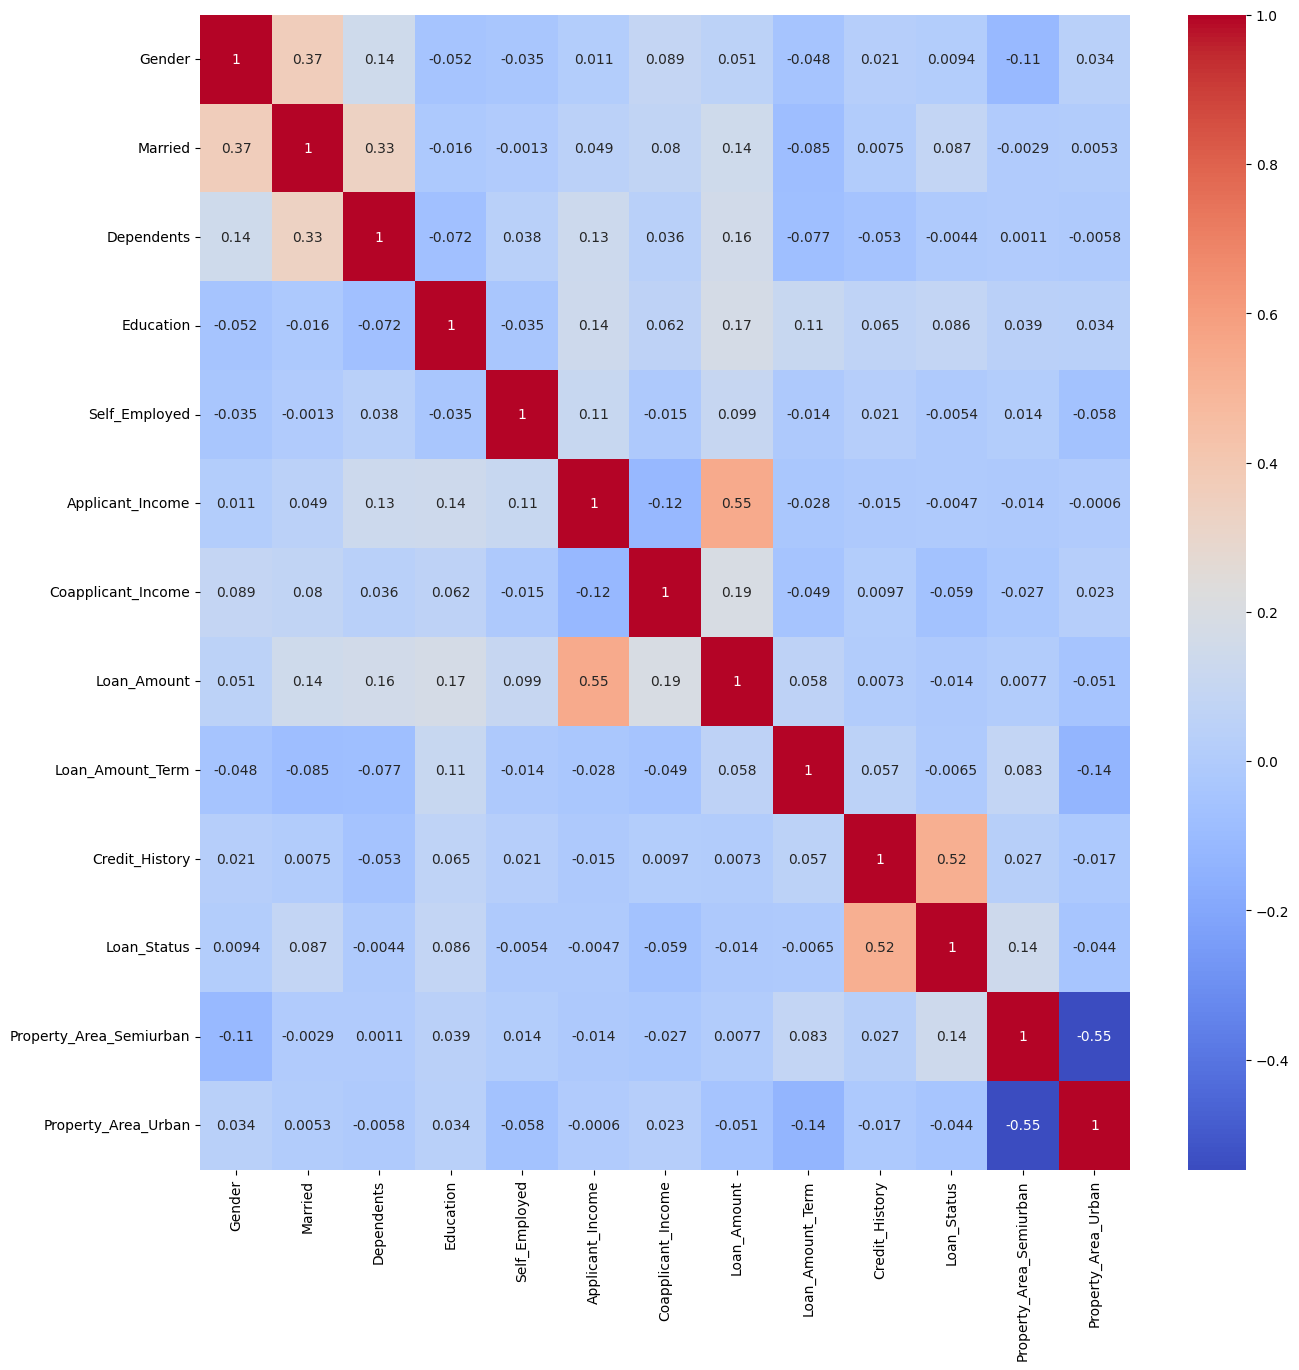

In [12]:
num_df = df.select_dtypes(include='number')

corr_matrix = num_df.corr()

plt.figure(figsize=(15,15))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

In [13]:
cor_target = abs(corr_matrix["Loan_Status"])

relevant_features = cor_target[cor_target>0.5]
relevant_features

Credit_History    0.523961
Loan_Status       1.000000
Name: Loan_Status, dtype: float64

In [14]:
X = df.drop(columns='Loan_Status')
Y = df['Loan_Status']

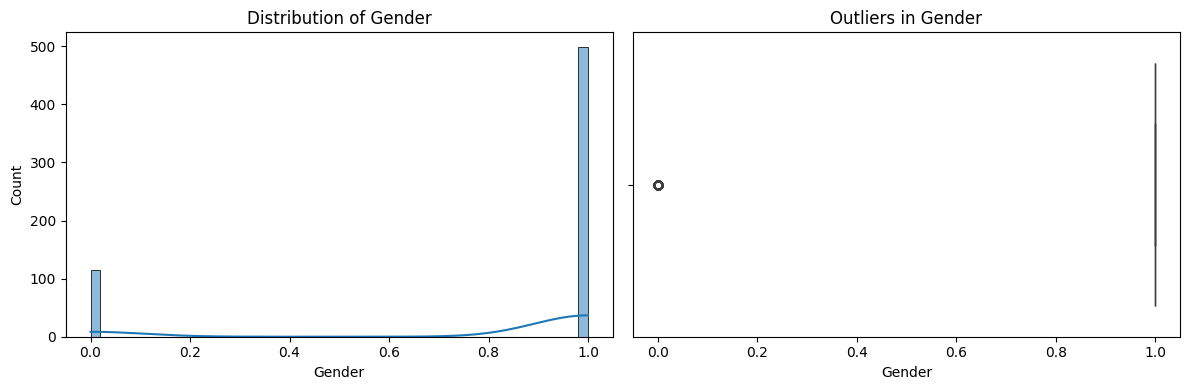

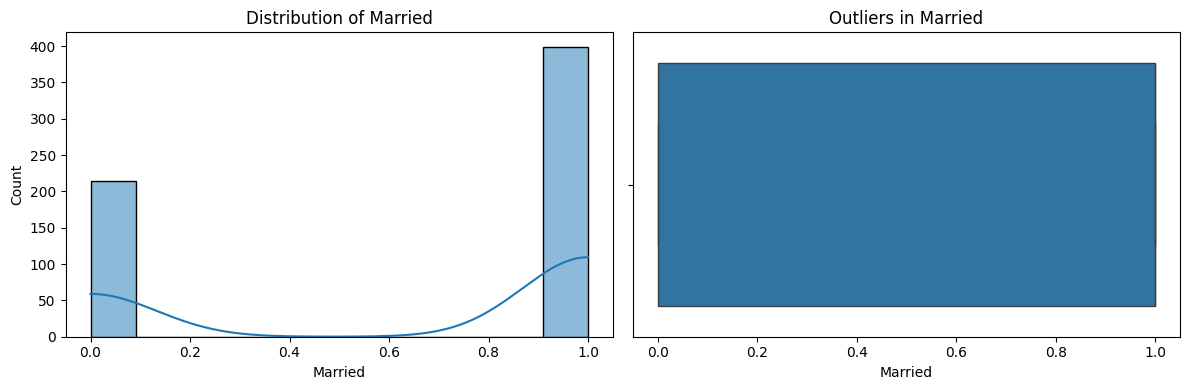

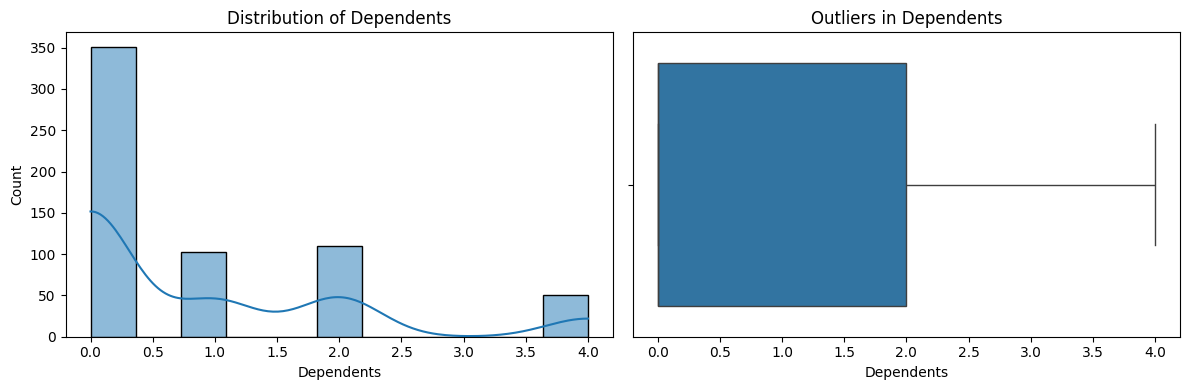

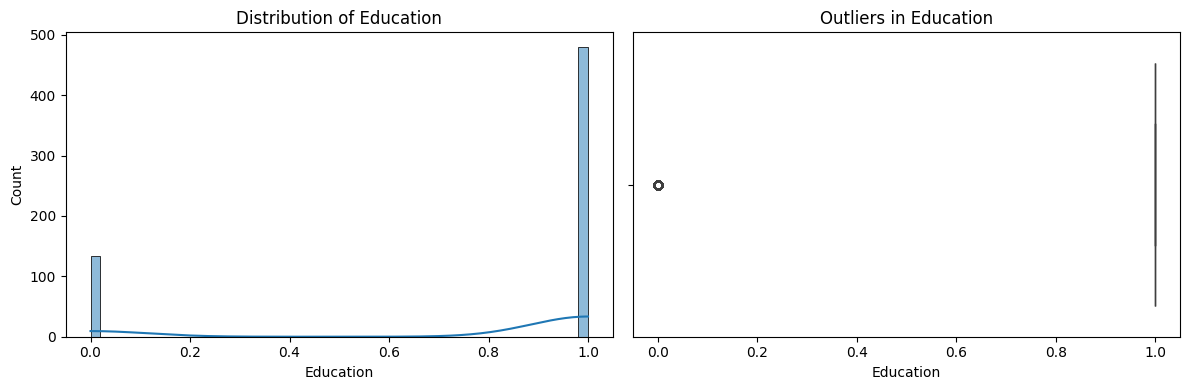

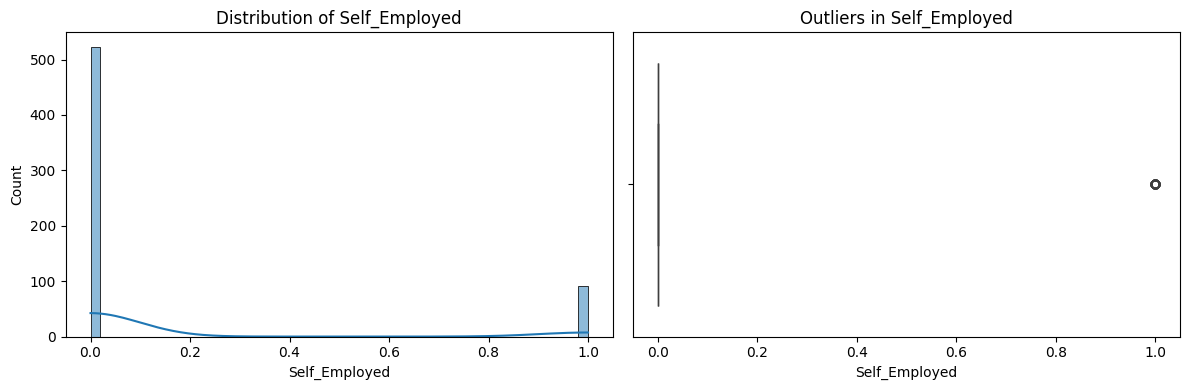

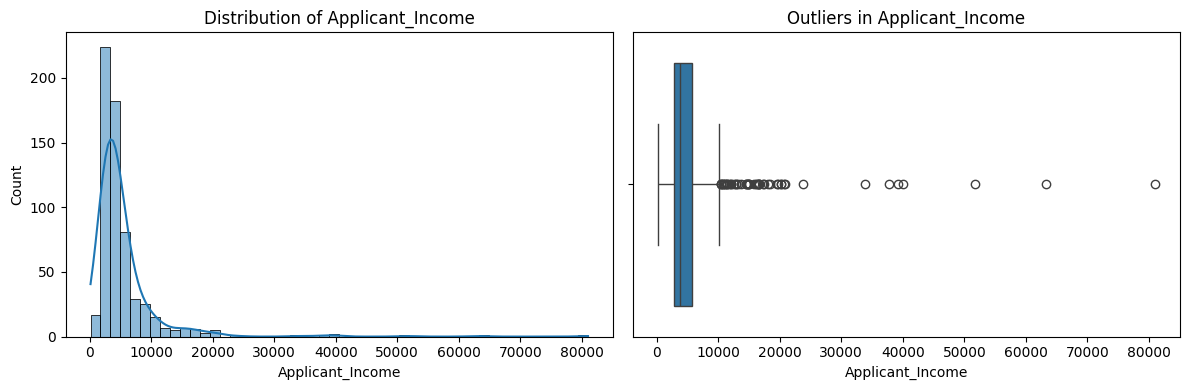

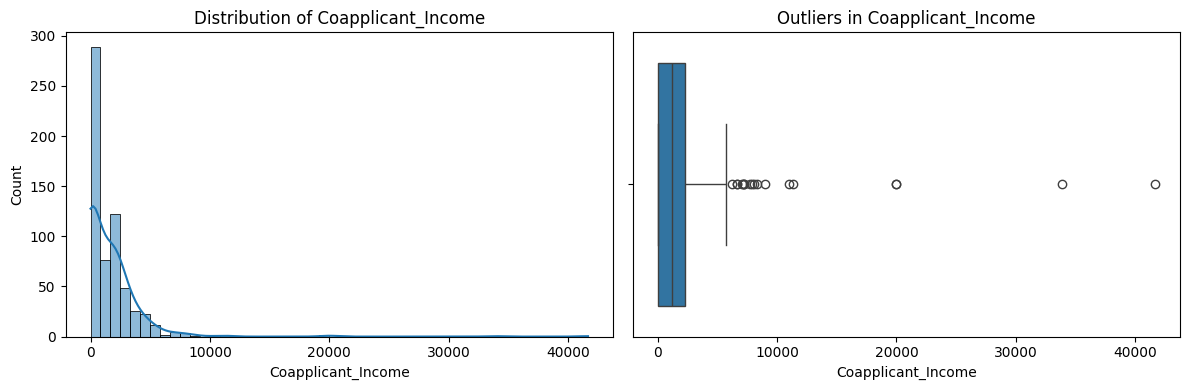

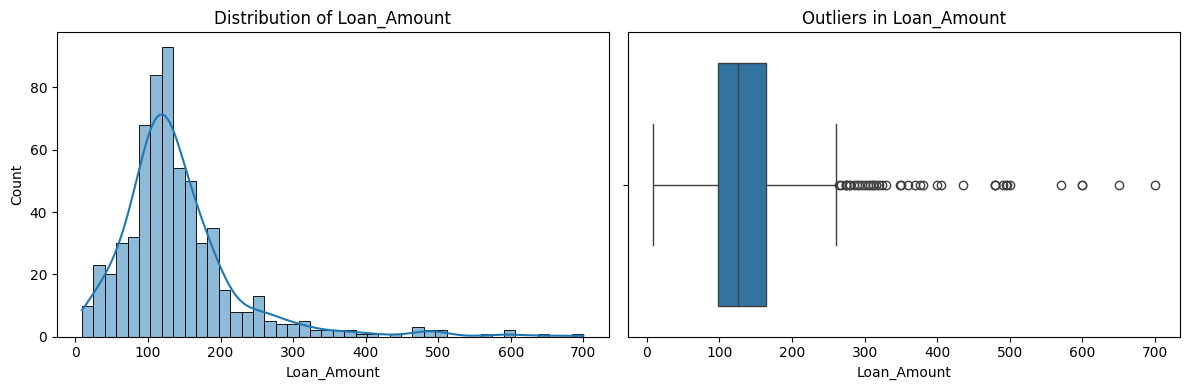

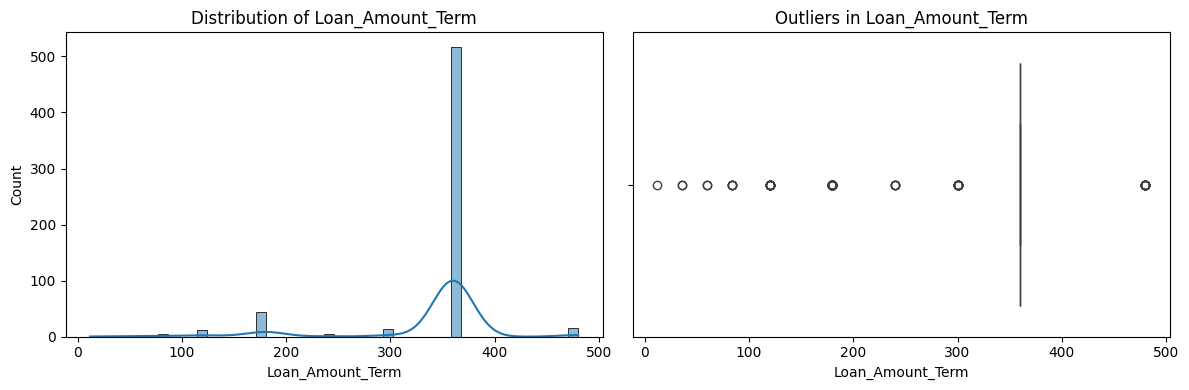

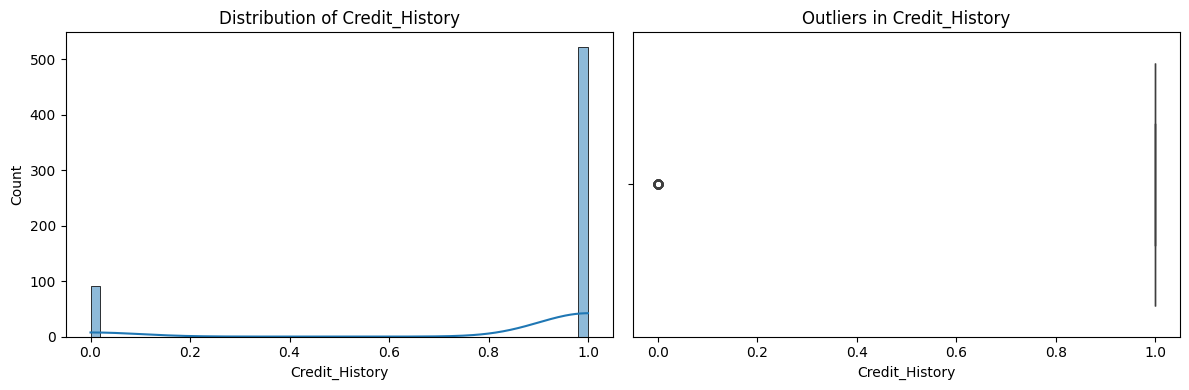

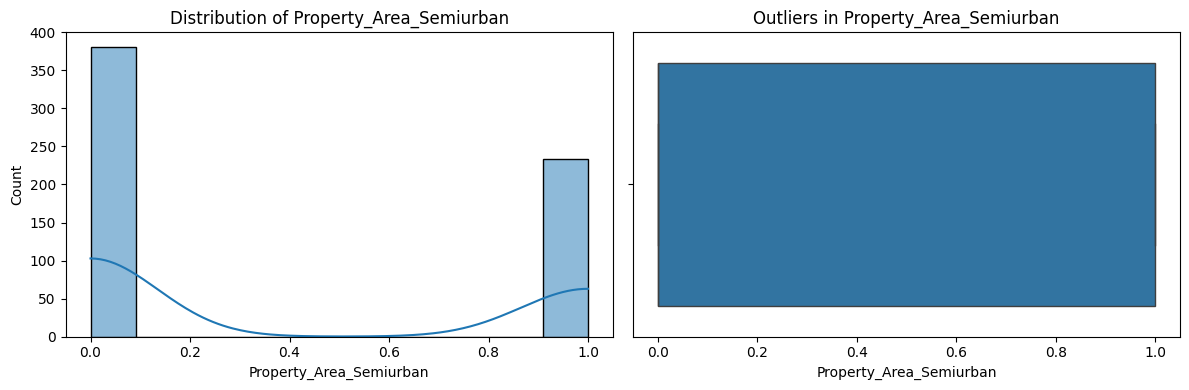

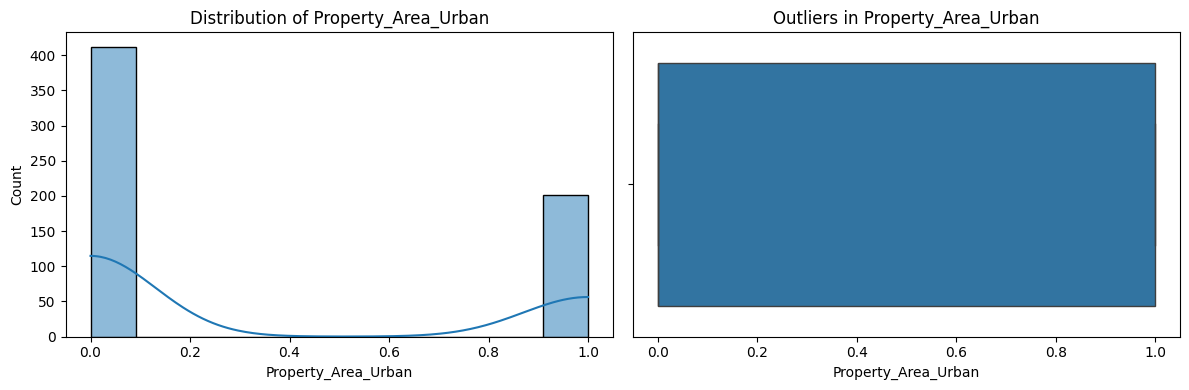

In [16]:
num_cols = X.select_dtypes(include='number').columns

for col in num_cols:
    fig, ax = plt.subplots(1, 2, figsize=(12,4))
    
    sns.histplot(df[col], kde=True, ax=ax[0])
    ax[0].set_title(f"Distribution of {col}")
    
    sns.boxplot(x=df[col], ax=ax[1])
    ax[1].set_title(f"Outliers in {col}")
    
    plt.tight_layout()
    plt.show()

In [17]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=42)

In [22]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, Y_train)

Y_predict = model.predict(X_test)

/Users/kavishkaimalsha/Desktop/Loan approval Prediction/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
print(f'Accuracy: {accuracy_score(Y_test, Y_predict)}')
print(f'\nClassification Report:\n {classification_report(Y_test, Y_predict)}')

Accuracy: 0.8211382113821138

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.47      0.63        40
           1       0.80      0.99      0.88        83

    accuracy                           0.82       123
   macro avg       0.87      0.73      0.76       123
weighted avg       0.85      0.82      0.80       123



**Feature Engineering**

In [24]:
X_FE = X
X_FE['Total_Income'] = X['Applicant_Income'] + X['Coapplicant_Income']
X_FE['Income_to_Loan'] = X['Total_Income'] / X['Loan_Amount']
X_FE['Log_Loan_Amount'] = np.log1p(X['Loan_Amount'])  # log(Loan_Amount + 1)

In [25]:
X_FE_train, X_FE_test, Y_FE_train, Y_FE_test = train_test_split(X, Y, test_size=0.2, shuffle=True, random_state=42)

In [27]:
model_FE = LogisticRegression(max_iter=1000)

model_FE.fit(X_FE_train, Y_FE_train)

Y_FE_Predict = model_FE.predict(X_FE_test)

/Users/kavishkaimalsha/Desktop/Loan approval Prediction/venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
print(f'Accuracy: {accuracy_score(Y_test, Y_FE_Predict)}')
print(f'\nClassification Report:\n {classification_report(Y_test, Y_FE_Predict)}')

Accuracy: 0.8292682926829268

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.50      0.66        40
           1       0.80      0.99      0.89        83

    accuracy                           0.83       123
   macro avg       0.88      0.74      0.77       123
weighted avg       0.85      0.83      0.81       123

